# IET SMP Assignment: Variational Autoencoders (VAE) with MNIST

**Total Marks: 20**

**Instructions:**
- Read each question carefully.
- Write the required code and brief explanations in the notebook cells provided.
- Run all code cells after completing the assignment.
- Keep your answers clear, concise, and well-organized.

### Assignment Overview
This notebook is structured as a short practical assignment on Variational Autoencoders using the MNIST dataset. You will define the model, train it, and generate new handwritten digit samples.

### Mark Distribution
- Concept of VAE and latent space: **3 marks**
- Encoder design and reparameterization trick: **5 marks**
- VAE loss function: **4 marks**
- Training setup and loop: **5 marks**
- Generating new digits and interpretation: **3 marks**


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### Question 1: VAE Concept, Encoder Design, and Reparameterization Trick [8 marks]

Explain the purpose of a Variational Autoencoder and how its latent space differs from that of a standard autoencoder.

Then describe how the VAE encoder produces the latent distribution parameters and why the reparameterization trick is required for backpropagation.

In your answer, include:
- the role of mean ($\mu$)
- the role of log-variance ($\log(\sigma^2)$)
- how $z = \mu + \sigma \odot \epsilon$ supports training

# Solution

The latent space of a regular autoencoder is potentially messy. Images are mapped to random locations and the generation could be messy. A VAE on the other hand has a latent space that is a distribution of values. This means all the similar images are clustered together. Instead of predicting the latent vector, we predict the mean, mu and the log of variance, logvar. Now, even if we don't sample sharply from the point of training we get good images.

The encoder outputs a distribution

1) The mean, mu, is used to tell where the distribution is located in the latent space.

2) The logvar is used to express how spread out it is

Both together define a distribution for input values. Since the output can be a positive or negative number, predicting the log ensures that the number is positive

We do z = mu + sigma * epsilion because the model needs to learn in the training step. If we use a random sampling opertaion, we cannot differentiate it. The model won't know how much a change in mu or logvar affects the loss. Hence the gradient flow breaks



In [ ]:
class VAE(nn.Module):
    def __init__(self, hidden_dim=256, latent_dim=20):
        super(VAE, self).__init__()

        self.encoder = nn.Sequential(
            
            nn.Conv2d(1, 64, kernel_size=2, padding=1, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=2, padding=1, stride=2),
            nn.Flatten()

        )

        # For MNIST the input_dimension is always 28x28 and one channel so I removed the input_dim param

        self.fc1 = nn.Linear(8192, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, 784)

    def encode(self, x):
        
        x = self.encoder(x)

        x = F.relu(self.fc1(x))

        mu = self.fc_mu(x)

        logvar = self.fc_logvar(x)

        return mu, logvar


    def reparameterize(self, mu, logvar):
       
       std = torch.exp(0.5 * logvar)

       epsilon = torch.randn_like(std)

       return mu + epsilon * std



    def decode(self, z):
        
        z = F.relu(self.fc3(z))

        z = torch.sigmoid(self.fc4(z))

        return z

        

    def forward(self, x):
        
        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        recon = self.decode(z)

        return recon, mu, logvar




model = VAE()
model = VAE().to(device)
print("VAE template ready for student implementation")


VAE template ready for student implementation


### Question 2: VAE Loss Function [4 mark]

Write the loss function for the VAE and briefly explain the purpose of each term.

Your response should include:
- reconstruction loss using binary cross entropy
- KL divergence and why it is needed

# Why KL Loss Is Required?

If KL loss isn't present in the VAE, it just becaomes an Autoencoder. The images may be placed anywhere in the latent space. So, if we want to generate an image and if the input isn't one of those values, we may generate garbage. Hence we use KL loss so that the images are placed in cluster like locations. This means that even if our input value is in between two image points, we still generate good images



In [8]:
def vae_loss(recon_x, x, mu, logvar):
    
    reconstruction_loss = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction = "sum")

    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return reconstruction_loss + kl_loss


### Question 3: Training the VAE on MNIST [5 marks]

Complete the training setup for the MNIST dataset and train the model for the required number of epochs.

Include:
- dataset loading and preprocessing
- optimizer selection
- forward pass, loss calculation, and parameter updates

# Solution

For this task I am loading the training dataset, with the Adam optimizer and I used BCE loss

In [ ]:
# Hyperparameters
batch_size = 128
epochs = 15
learning_rate = 1e-3

# Data transformation and loading
transform = transforms.ToTensor()
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

model.train()

for epoch in range(epochs):

    losses = []

    for images, _ in train_loader:

        images = images.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(images)

        loss = vae_loss(recon, images, mu, logvar)

        loss.backward()

        losses.append(loss.item())

        optimizer.step()

    print(f"Epoch {epoch}")

    print(f"Average loss {sum(losses) / len(losses)}")

        


Epoch 0
Average loss 21403.78210995802
Epoch 1
Average loss 16094.796391924307
Epoch 2
Average loss 15122.423488722681
Epoch 3
Average loss 14703.407107875799
Epoch 4
Average loss 14446.673176389259
Epoch 5
Average loss 14268.31542135861
Epoch 6
Average loss 14143.008668293576
Epoch 7
Average loss 14037.961049940031
Epoch 8
Average loss 13953.705763176305
Epoch 9
Average loss 13887.477584871402
Epoch 10
Average loss 13830.55158707023
Epoch 11
Average loss 13781.072238556104
Epoch 12
Average loss 13734.710900019989
Epoch 13
Average loss 13699.503183718683
Epoch 14
Average loss 13673.678461070762


### Question 4: Generating New Digits [3 mark]

Use the trained decoder to generate new handwritten digits from random latent vectors.

Then briefly comment on the quality of the generated samples and what this suggests about the learned latent space.

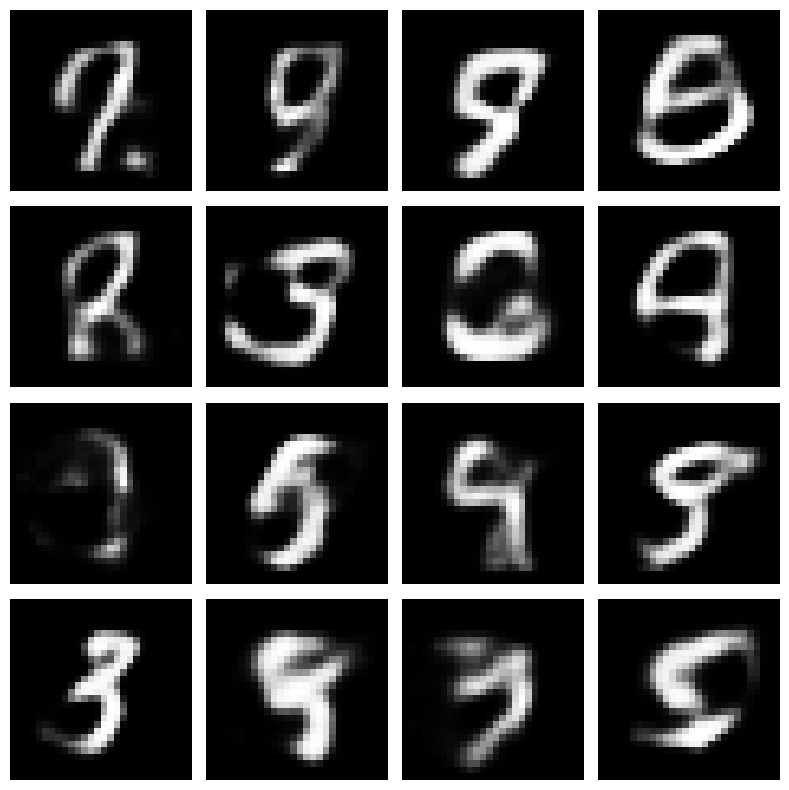

In [ ]:
model.eval()

num_samples = 16

# Generating a few samples to see

with torch.no_grad():

    z = torch.randn(num_samples, model.fc3.in_features).to(device)

    generated = model.decode(z)

    generated = generated.view(num_samples, 28, 28)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):

    ax.imshow(generated[i].cpu().numpy(), cmap="gray")

    ax.axis("off")

plt.tight_layout()

plt.show()


# Images Generated

The images are slightly blurry, but we can see the digits generated and indentify them. Since it is blurry, I would say that the latent space is regularized to agressively. This means that the KL Loss is forcing the distribution to look like a normal distribution too strongly